# Optimising Plate and Cone Position

In [30]:
import sys
from pathlib import Path
import os
import subprocess
# adjust the number of .parent calls to match your notebook's depth from repo root
repo_root = Path.cwd().resolve().parents[1]   # e.g. if notebook is 2 levels deep
sys.path.append(str(repo_root))

from molflow_sweep import FacetRef, SweepConfig, MolflowSweep

import optuna
# You can use Matplotlib instead of Plotly for visualization by simply replacing `optuna.visualization` with
# `optuna.visualization.matplotlib` in the following examples.
from optuna.visualization.matplotlib import plot_contour
from optuna.visualization.matplotlib import plot_edf
from optuna.visualization.matplotlib import plot_intermediate_values
from optuna.visualization.matplotlib import plot_optimization_history
from optuna.visualization.matplotlib import plot_parallel_coordinate
from optuna.visualization.matplotlib import plot_param_importances
from optuna.visualization.matplotlib import plot_rank
from optuna.visualization.matplotlib import plot_slice
from optuna.visualization.matplotlib import plot_timeline


In [ ]:

PLATE = ["plate_front", "plate_back"]


#cone has 36 facets, plus front and back, so 38 in total
CONE = ["cfront","cback","c1", "c2", "c3", "c4", "c5", "c6", "c7", "c8", "c9", "c10","c11", "c12", "c13", "c14", "c15", "c16", "c17", "c18", "c19", "c20","c21", "c22", "c23", "c24", "c25", "c26", "c27", "c28", "c29", "c30", "c31", "c32", "c33", "c34", "c35", "c36"]

cfg = SweepConfig(
    molflow_exe=r"C:\Users\ASUS\Documents\molflow_win_2.11.1\molflowCLI.exe",
    base_geometry=r"C:\Users\ASUS\Documents\CERN\Molfow_Sweep\geometries\simplified_target_baseplate_cone.xml",
    out_dir="C:\Users\ASUS\Documents\CERN\Molfow_Sweep\experiments\6_optimisation_meshplate\sweep_runs",

    facets={
        "plate_front": FacetRef("plate_front", xml_id=175, csv_id=176),
        "plate_back":  FacetRef("plate_back", xml_id=176, csv_id=177),
        "deflector": FacetRef("deflector", xml_id=252, csv_id=253),
        "cfront": FacetRef("cfront", xml_id=255, csv_id=256),
        "cback": FacetRef("cback", xml_id=256, csv_id=257),
        "c1": FacetRef("c1", xml_id=257, csv_id=258),
        "c2": FacetRef("c2", xml_id=258, csv_id=259),
        "c3": FacetRef("c3", xml_id=259, csv_id=260),
        "c4": FacetRef("c4", xml_id=260, csv_id=261),
        "c5": FacetRef("c5", xml_id=261, csv_id=262),
        "c6": FacetRef("c6", xml_id=262, csv_id=263),
        "c7": FacetRef("c7", xml_id=263, csv_id=264),
        "c8": FacetRef("c8", xml_id=264, csv_id=265),
        "c9": FacetRef("c9", xml_id=265, csv_id=266),
        "c10": FacetRef("c10", xml_id=266, csv_id=267),
        "c11": FacetRef("c11", xml_id=267, csv_id=268),
        "c12": FacetRef("c12", xml_id=268, csv_id=269),
        "c13": FacetRef("c13", xml_id=269, csv_id=270),
        "c14": FacetRef("c14", xml_id=270, csv_id=271),
        "c15": FacetRef("c15", xml_id=271, csv_id=272),
        "c16": FacetRef("c16", xml_id=272, csv_id=273),
        "c17": FacetRef("c17", xml_id=273, csv_id=274),
        "c18": FacetRef("c18", xml_id=274, csv_id=275),
        "c19": FacetRef("c19", xml_id=275, csv_id=276),
        "c20": FacetRef("c20", xml_id=276, csv_id=277),
        "c21": FacetRef("c21", xml_id=277, csv_id=278),
        "c22": FacetRef("c22", xml_id=278, csv_id=279),
        "c23": FacetRef("c23", xml_id=279, csv_id=280),
        "c24": FacetRef("c24", xml_id=280, csv_id=281),
        "c25": FacetRef("c25", xml_id=281, csv_id=282),
        "c26": FacetRef("c26", xml_id=282, csv_id=283),
        "c27": FacetRef("c27", xml_id=283, csv_id=284),
        "c28": FacetRef("c28", xml_id=284, csv_id=285),
        "c29": FacetRef("c29", xml_id=285, csv_id=286),
        "c30": FacetRef("c30", xml_id=286, csv_id=287),
        "c31": FacetRef("c31", xml_id=287, csv_id=288),
        "c32": FacetRef("c32", xml_id=288, csv_id=289),
        "c33": FacetRef("c33", xml_id=289, csv_id=290),
        "c34": FacetRef("c34", xml_id=290, csv_id=291),
        "c35": FacetRef("c35", xml_id=291, csv_id=292),
        "c36": FacetRef("c36", xml_id=292, csv_id=293),
    },
    move_facets=CONE,
    result_facets=PLATE + CONE + ["deflector"],
    axis=0,
    ndes="1e5",
    threads="8",
)

sweep = MolflowSweep(cfg)

sweep = MolflowSweep(cfg)

In [32]:
def run_cli_opacity(geom_path, run_dir,plate_opacity):

       """Run molflowCLI on `geom_path`; return path to facet_details.csv."""
       plate_front_id = sweep.cfg.facets["plate_front"].csv_id
       plate_back_id = sweep.cfg.facets["plate_back"].csv_id

       run_dir.mkdir(parents=True, exist_ok=True)
       cmd = [os.path.abspath(sweep.cfg.molflow_exe),
              "-f", os.path.abspath(geom_path),
              "-d", sweep.cfg.ndes, "-j", sweep.cfg.threads,
              "--reset", "--outputPath", "results",
              "--writeFacetDetails", "--noProgress",
              "--setParams", f"facet.{plate_front_id}.opacity={plate_opacity}", f"facet.{plate_back_id}.opacity={plate_opacity}"]
       
       print("  $", " ".join(cmd))
       subprocess.run(cmd, cwd=run_dir, check=True)
       return run_dir / "results" / "facet_details.csv"


In [33]:
def evaluate_opacity(moves, run_id,plate_opacity):
    """similiar to .evaluate method, but modified to allow changes to the cli command do optimise opactiy"""

    run_dir = sweep.cfg.out_dir / f"run_{run_id}"
    geom = sweep.cfg.out_dir / f"geom_{run_id}.xml"
    sweep.cfg.out_dir.mkdir(parents=True, exist_ok=True)

    sweep.write_shifted_geometry(geom, moves)
    csv_path = run_cli_opacity(geom, run_dir, plate_opacity)
    result = sweep.extract(csv_path)
    sweep._log_run(run_id, moves, str(run_dir))
    return result

In [34]:
def objective(trial):
    # Suggest values for the parameters to optimize
    plate_off = trial.suggest_float('plate_offset', -0.25, 10.0)  # Plate offset between -0.25 and 10.0 cm
    cone_off = trial.suggest_float('cone_offset', -0.75, 0.75)  # Cone offset between -0.25 and 0.75 cm
    opacity = trial.suggest_float('opacity', 0.0, 1.0)
    # Evaluate the sweep with the suggested parameters
    row = evaluate_opacity(
        moves=[(PLATE, 0, plate_off),   # facets, axis, offset
               (CONE, 0, cone_off+plate_off)],  # Adjust cone offset relative to plate
        run_id=f"Plate_{plate_off:.3f}_Cone_{cone_off:.3f}_Opacity{opacity:.3f}",
        plate_opacity = opacity)
    

    # Return the objective value (hit fraction on back of plate)
    return row['plate_back_equiv_abs'] / row['total_des']  # Hit fraction on back of plate  

In [35]:
study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.GPSampler(),
                            )  # We want to maximize the fraction that hit the back plate 


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22848\2331773744.py:2: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  sampler=optuna.samplers.GPSampler(),
[I 2026-07-23 13:40:07,474] A new study created in memory with name: no-name-1c0201af-5503-4002-9001-8fbebf52897e


In [ ]:
study.optimize(objective,n_trials=20)

  $ C:\Users\ASUS\Documents\molflow_win_2.11.1\molflowCLI.exe -f C:\Users\ASUS\Documents\CERN\Molfow_Sweep\sweep_runs\geom_Plate_10.000_Cone_-0.750_Opacity1.000.xml -d 1e5 -j 8 --reset --outputPath results --writeFacetDetails --noProgress --setParams facet.176.opacity=1.0 facet.177.opacity=1.0


[I 2026-07-23 16:40:19,051] Trial 20 finished with value: 0.03951 and parameters: {'plate_offset': 9.999999999999998, 'cone_offset': -0.75, 'opacity': 1.0}. Best is trial 18 with value: 0.08012.


  $ C:\Users\ASUS\Documents\molflow_win_2.11.1\molflowCLI.exe -f C:\Users\ASUS\Documents\CERN\Molfow_Sweep\sweep_runs\geom_Plate_1.871_Cone_0.210_Opacity1.000.xml -d 1e5 -j 8 --reset --outputPath results --writeFacetDetails --noProgress --setParams facet.176.opacity=1.0 facet.177.opacity=1.0


[I 2026-07-23 16:42:14,319] Trial 21 finished with value: 0.08296 and parameters: {'plate_offset': 1.8708708861092562, 'cone_offset': 0.2095509640005364, 'opacity': 1.0}. Best is trial 21 with value: 0.08296.


  $ C:\Users\ASUS\Documents\molflow_win_2.11.1\molflowCLI.exe -f C:\Users\ASUS\Documents\CERN\Molfow_Sweep\sweep_runs\geom_Plate_-0.250_Cone_0.045_Opacity1.000.xml -d 1e5 -j 8 --reset --outputPath results --writeFacetDetails --noProgress --setParams facet.176.opacity=1.0 facet.177.opacity=1.0


...

  $ C:\Users\ASUS\Documents\molflow_win_2.11.1\molflowCLI.exe -f C:\Users\ASUS\Documents\CERN\Molfow_Sweep\sweep_runs\geom_Plate_1.511_Cone_-0.033_Opacity1.000.xml -d 1e5 -j 8 --reset --outputPath results --writeFacetDetails --noProgress --setParams facet.176.opacity=1.0 facet.177.opacity=1.0


[I 2026-07-23 17:15:42,613] Trial 26 finished with value: 0.08707 and parameters: {'plate_offset': 1.5106652922222628, 'cone_offset': -0.03332771988969474, 'opacity': 1.0}. Best is trial 24 with value: 0.08734.


  $ C:\Users\ASUS\Documents\molflow_win_2.11.1\molflowCLI.exe -f C:\Users\ASUS\Documents\CERN\Molfow_Sweep\sweep_runs\geom_Plate_1.297_Cone_0.009_Opacity1.000.xml -d 1e5 -j 8 --reset --outputPath results --writeFacetDetails --noProgress --setParams facet.176.opacity=1.0 facet.177.opacity=1.0


[I 2026-07-23 17:17:07,030] Trial 27 finished with value: 0.08899 and parameters: {'plate_offset': 1.2969291887775694, 'cone_offset': 0.009409509316154141, 'opacity': 1.0}. Best is trial 27 with value: 0.08899.


  $ C:\Users\ASUS\Documents\molflow_win_2.11.1\molflowCLI.exe -f C:\Users\ASUS\Documents\CERN\Molfow_Sweep\sweep_runs\geom_Plate_1.136_Cone_0.064_Opacity1.000.xml -d 1e5 -j 8 --reset --outputPath results --writeFacetDetails --noProgress --setParams facet.176.opacity=1.0 facet.177.opacity=1.0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22848\3324289224.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

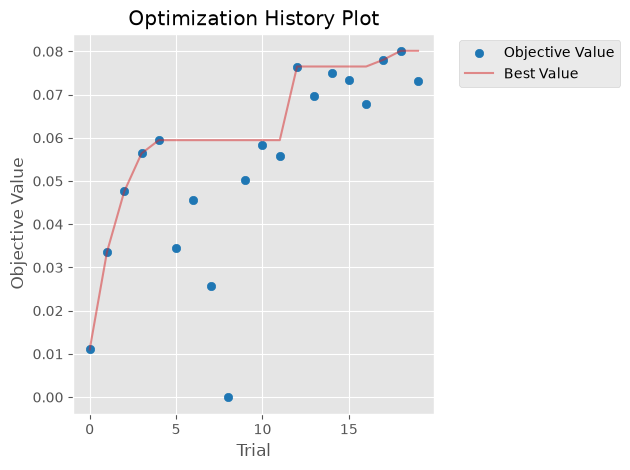

In [ ]:
plot_optimization_history(study)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22848\927314822.py:1: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  plot_contour(study)


array([[<Axes: xlabel='cone_offset', ylabel='cone_offset'>,
        <Axes: xlabel='opacity', ylabel='cone_offset'>,
        <Axes: xlabel='plate_offset', ylabel='cone_offset'>],
       [<Axes: xlabel='cone_offset', ylabel='opacity'>,
        <Axes: xlabel='opacity', ylabel='opacity'>,
        <Axes: xlabel='plate_offset', ylabel='opacity'>],
       [<Axes: xlabel='cone_offset', ylabel='plate_offset'>,
        <Axes: xlabel='opacity', ylabel='plate_offset'>,
        <Axes: xlabel='plate_offset', ylabel='plate_offset'>]],
      dtype=object)

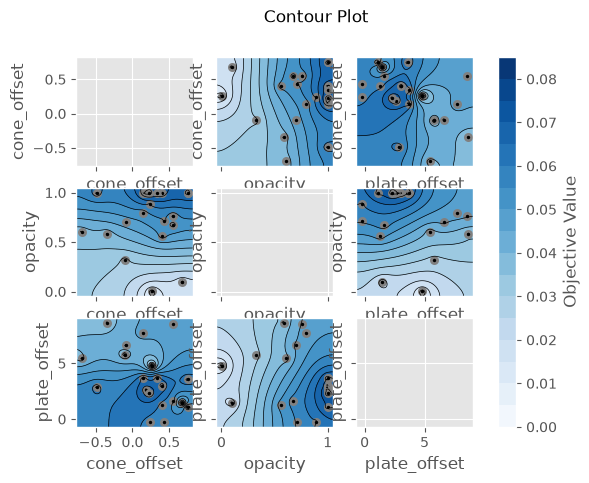

In [ ]:
plot_contour(study)

In [ ]:
plot_param_importances(study)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22848\3836449081.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


ImportError: Tried to import 'sklearn' but failed. Please make sure that the package is installed correctly to use this feature. Actual error: No module named 'sklearn'.

In [ ]:
print("Best params: ", study.best_params)
print("Best value: ", study.best_value)
print("Best Trial: ", study.best_trial)
print("Trials: ", study.trials)

Best params:  {'plate_offset': 2.3046981263762705, 'cone_offset': 0.22526176746620297, 'opacity': 1.0}
Best value:  0.08012
Best Trial:  FrozenTrial(number=18, state=<TrialState.COMPLETE: 1>, values=[0.08012], datetime_start=datetime.datetime(2026, 7, 23, 14, 1, 28, 736020), datetime_complete=datetime.datetime(2026, 7, 23, 14, 2, 37, 700528), params={'plate_offset': 2.3046981263762705, 'cone_offset': 0.22526176746620297, 'opacity': 1.0}, user_attrs={}, system_attrs={'gp:relative_params:0': '{"cone_offset": 0.22526176746620297, "opacity": 1.0, "plate_offset": 2.3046981263762705}'}, intermediate_values={}, distributions={'plate_offset': FloatDistribution(high=10.0, log=False, low=-0.25, step=None), 'cone_offset': FloatDistribution(high=0.75, log=False, low=-0.75, step=None), 'opacity': FloatDistribution(high=1.0, log=False, low=0.0, step=None)}, trial_id=18, value=None)
Trials:  [FrozenTrial(number=0, state=<TrialState.COMPLETE: 1>, values=[0.01102], datetime_start=datetime.datetime(2026